# Прогнозирование задержки прибытия авиарейса

**Задача:** бинарная классификация. Требуется определить, прибудет ли рейс
с опозданием более 15 минут относительно расписания. Порог в 15 минут —
официальный критерий задержки, используемый Bureau of Transportation
Statistics (США).

**Данные:** выборка из набора *Flight Delay and Cancellation Dataset
(2019–2023)*, опубликованного на Kaggle. Исходный набор содержит около
30 млн рейсов; для работы случайным образом отобрано ~59 тыс. записей
равномерно по всему периоду наблюдений.

**Постановка:** прогноз выполняется в момент, когда самолёт уже вылетел, но
ещё не приземлился. Такой сценарий соответствует реальной задаче
авиаперевозчика — заблаговременно предупредить пассажиров стыковочных
рейсов. Следовательно, модели доступны фактическая задержка вылета и время
руления, но недоступны любые сведения о самом прибытии.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay)

from pickle import dump
from pathlib import Path

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1. Загрузка данных

In [2]:
df = pd.read_csv("../data/flights-sample.csv",
                 dtype={"CANCELLATION_CODE": "string"})

print(f"Загружено записей: {len(df)}")
print(f"Колонок: {df.shape[1]}")
df.head()

Загружено записей: 58761
Колонок: 32


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-12-26,Allegiant Air,Allegiant Air: G4,G4,20368,1648,PVD,"Providence, RI",PGD,"Punta Gorda, FL",...,0.0,200.0,199.0,161.0,1184.0,NaN,NaN,NaN,NaN,NaN
1,2020-02-24,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5817,RNO,"Reno, NV",SFO,"San Francisco, CA",...,0.0,87.0,63.0,46.0,192.0,NaN,NaN,NaN,NaN,NaN
2,2019-08-03,Republic Airline,Republic Airline: YX,YX,20452,3401,CLT,"Charlotte, NC",EWR,"Newark, NJ",...,0.0,117.0,128.0,72.0,529.0,NaN,NaN,NaN,NaN,NaN
3,2019-06-21,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,852,JFK,"New York, NY",ORD,"Chicago, IL",...,0.0,170.0,151.0,117.0,740.0,NaN,NaN,NaN,NaN,NaN
4,2020-03-25,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1692,CLT,"Charlotte, NC",PIT,"Pittsburgh, PA",...,0.0,86.0,NaN,NaN,366.0,NaN,NaN,NaN,NaN,NaN


In [3]:
flight_date = pd.to_datetime(df["FL_DATE"])
print(f"Период наблюдений: {flight_date.min().date()} — "
      f"{flight_date.max().date()}")

missing = (df.isna().mean() * 100).round(2)
print("\nДоля пропусков по колонкам, %:")
print(missing[missing > 0].to_string())

Период наблюдений: 2019-01-01 — 2023-08-31

Доля пропусков по колонкам, %:
DEP_TIME                    2.58
DEP_DELAY                   2.58
TAXI_OUT                    2.63
WHEELS_OFF                  2.63
WHEELS_ON                   2.65
TAXI_IN                     2.65
ARR_TIME                    2.65
ARR_DELAY                   2.86
CANCELLATION_CODE          97.36
ELAPSED_TIME                2.86
AIR_TIME                    2.86
DELAY_DUE_CARRIER          82.28
DELAY_DUE_WEATHER          82.28
DELAY_DUE_NAS              82.28
DELAY_DUE_SECURITY         82.28
DELAY_DUE_LATE_AIRCRAFT    82.28


## 2. Отбор признаков и проблема утечки целевой переменной

Исходный набор содержит 32 колонки, однако большая их часть непригодна для
построения модели.

**Утечка целевой переменной.** Колонки `ARR_TIME`, `ELAPSED_TIME`,
`AIR_TIME`, а также пять колонок `DELAY_DUE_*` заполняются уже после
прибытия рейса. Более того, `DELAY_DUE_*` представляют собой разложение
самой задержки по причинам, то есть напрямую содержат целевую переменную.
Их использование дало бы формально высокое качество при полной
непригодности модели: на этапе инференса таких данных не существует.

**Допустимые признаки.** Величины `DEP_DELAY` (фактическая задержка вылета)
и `TAXI_OUT` (время руления перед взлётом) становятся известны до прибытия
рейса, поэтому в выбранной постановке задачи утечкой не являются.

**Отвергнутые признаки.** Коды аэропортов `ORIGIN` и `DEST` содержат более
360 уникальных значений каждый. Эксперимент показал, что их включение
повышает ROC-AUC лишь на 0.001 при увеличении размерности признакового
пространства на 700 столбцов после one-hot кодирования и необходимости
передавать два дополнительных поля в каждом запросе к сервису. Признаки
исключены как неинформативные.

In [4]:
CATEGORICAL = ["AIRLINE"]
NUMERIC = ["MONTH", "DAY_OF_WEEK", "CRS_DEP_TIME", "CRS_ELAPSED_TIME",
           "DISTANCE", "DEP_DELAY", "TAXI_OUT"]
FEATURES = CATEGORICAL + NUMERIC

DELAY_THRESHOLD = 15

print("Признаки, подаваемые на вход конвейера:")
for name in FEATURES:
    kind = "категориальный" if name in CATEGORICAL else "числовой"
    print(f"  {name:20s} — {kind}")

Признаки, подаваемые на вход конвейера:
  AIRLINE              — категориальный
  MONTH                — числовой
  DAY_OF_WEEK          — числовой
  CRS_DEP_TIME         — числовой
  CRS_ELAPSED_TIME     — числовой
  DISTANCE             — числовой
  DEP_DELAY            — числовой
  TAXI_OUT             — числовой


## 3. Предварительная очистка данных

Отменённые и отклонённые от маршрута рейсы исключаются: для них понятие
задержки прибытия не определено. Также удаляются записи с отсутствующим
значением `ARR_DELAY`, поскольку по ним невозможно построить целевую
переменную.

Признаки `MONTH` и `DAY_OF_WEEK` выделяются из даты рейса. Эта операция
выполняется здесь, а не внутри конвейера, чтобы конвейер содержал только
стандартные преобразования `Scikit-Learn` и корректно восстанавливался из
файла в сервисе инференса без импорта пользовательского кода.

In [5]:
data = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)].copy()
data = data.dropna(subset=["ARR_DELAY"])

flight_date = pd.to_datetime(data["FL_DATE"])
data["MONTH"] = flight_date.dt.month
data["DAY_OF_WEEK"] = flight_date.dt.dayofweek + 1

X = data[FEATURES]
y = (data["ARR_DELAY"] >= DELAY_THRESHOLD).astype(int)

print(f"Записей до очистки:    {len(df)}")
print(f"Записей после очистки: {len(data)}")
print(f"\nРаспределение классов:")
print(y.value_counts(normalize=True).rename({0: "вовремя", 1: "задержан"}).round(3).to_string())

Записей до очистки:    58761
Записей после очистки: 57078

Распределение классов:
вовремя     0.818
задержан    0.182


## 4. Разведочный анализ

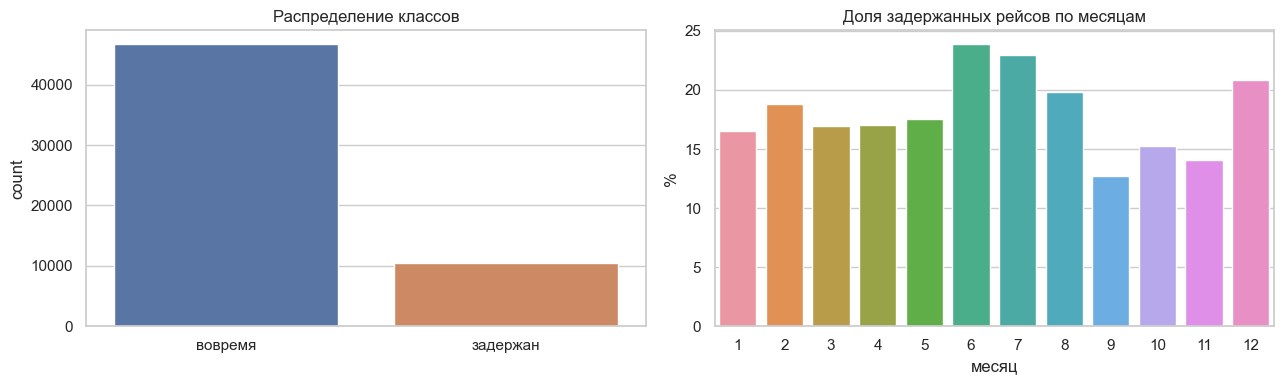

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x=y.map({0: "вовремя", 1: "задержан"}), ax=axes[0])
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("")

delay_by_month = y.groupby(data["MONTH"]).mean() * 100
sns.barplot(x=delay_by_month.index, y=delay_by_month.values, ax=axes[1])
axes[1].set_title("Доля задержанных рейсов по месяцам")
axes[1].set_xlabel("месяц")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

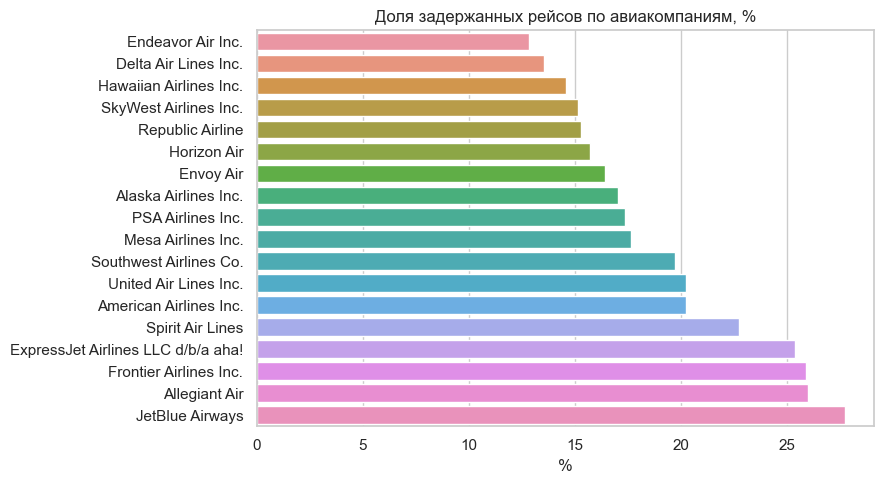

In [7]:
delay_by_airline = (y.groupby(data["AIRLINE"]).mean() * 100).sort_values()

plt.figure(figsize=(9, 5))
sns.barplot(x=delay_by_airline.values, y=delay_by_airline.index)
plt.title("Доля задержанных рейсов по авиакомпаниям, %")
plt.xlabel("%")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [8]:
print("Описательная статистика числовых признаков:")
X[NUMERIC].describe().round(1)

Описательная статистика числовых признаков:


,MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ELAPSED_TIME,DISTANCE,DEP_DELAY,TAXI_OUT
count,57078.0,57078.0,57078.0,57078.0,57078.0,57078.0,57078.0
mean,6.3,4.0,1328.0,142.1,808.5,10.2,16.6
std,3.4,2.0,486.0,71.9,591.6,49.3,9.2
min,1.0,1.0,1.0,22.0,31.0,-40.0,2.0
25%,3.0,2.0,915.0,90.0,373.0,-6.0,11.0
50%,6.0,4.0,1319.0,125.0,651.0,-2.0,14.0
75%,9.0,6.0,1731.0,172.0,1044.0,6.0,19.0
max,12.0,7.0,2359.0,685.0,5095.0,2250.0,189.0


## 5. Построение конвейера

Конвейер объединяет предварительную обработку данных и саму модель в единый
объект. Такой подход обязателен для сервиса инференса: сохранённый объект
принимает на вход сырые, необработанные данные, а вся их подготовка
выполняется внутри него теми же преобразованиями и с теми же параметрами,
что были получены на этапе обучения.

Числовые признаки проходят заполнение пропусков медианой и стандартизацию,
категориальный признак — one-hot кодирование. Параметр
`handle_unknown="ignore"` обеспечивает устойчивость сервиса к запросам с
неизвестной авиакомпанией: вместо исключения будет сформирован нулевой
вектор.

Классы несбалансированы (примерно 82% против 18%), поэтому используется
параметр `class_weight="balanced"`, автоматически повышающий вес редкого
класса обратно пропорционально его частоте.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(transformers=[
    ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("numeric", numeric_transformer, NUMERIC),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000,
                                      class_weight="balanced",
                                      random_state=RANDOM_STATE)),
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['AIRLINE']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MONTH', 'DAY_OF_WEEK',
                                                   'CRS_DEP_TIME',
                                                   'CRS_ELAPSED_TIME',
                                                   'DISTANCE', 'DEP_DELAY',
                                                   'TAXI_OUT'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

## 6. Обучение и подбор гиперпараметров

Выборка разделяется на обучающую и тестовую части в соотношении 80/20 со
стратификацией по целевой переменной — это сохраняет исходное соотношение
классов в обеих частях. Гиперпараметр регуляризации подбирается перекрёстной
проверкой по пяти блокам, критерий — ROC-AUC.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка:  {len(X_test)}")

Обучающая выборка: 45662
Тестовая выборка:  11416


In [11]:
param_grid = {"classifier__C": [0.01, 0.1, 1.0, 10.0]}

search_cv = GridSearchCV(pipeline, param_grid, cv=5,
                         scoring="roc_auc", n_jobs=-1)
search_cv.fit(X_train, y_train)

print(f"Лучшее значение C: {search_cv.best_params_['classifier__C']}")
print(f"ROC-AUC на кросс-валидации: {search_cv.best_score_:.4f}")

model = search_cv.best_estimator_

Лучшее значение C: 0.1
ROC-AUC на кросс-валидации: 0.9626


## 7. Оценка качества

In [12]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred,
                           target_names=["вовремя", "задержан"]))

Accuracy : 0.9228
F1-score : 0.8074
ROC-AUC  : 0.9632

              precision    recall  f1-score   support

     вовремя       0.97      0.93      0.95      9333
    задержан       0.74      0.89      0.81      2083

    accuracy                           0.92     11416
   macro avg       0.86      0.91      0.88     11416
weighted avg       0.93      0.92      0.93     11416



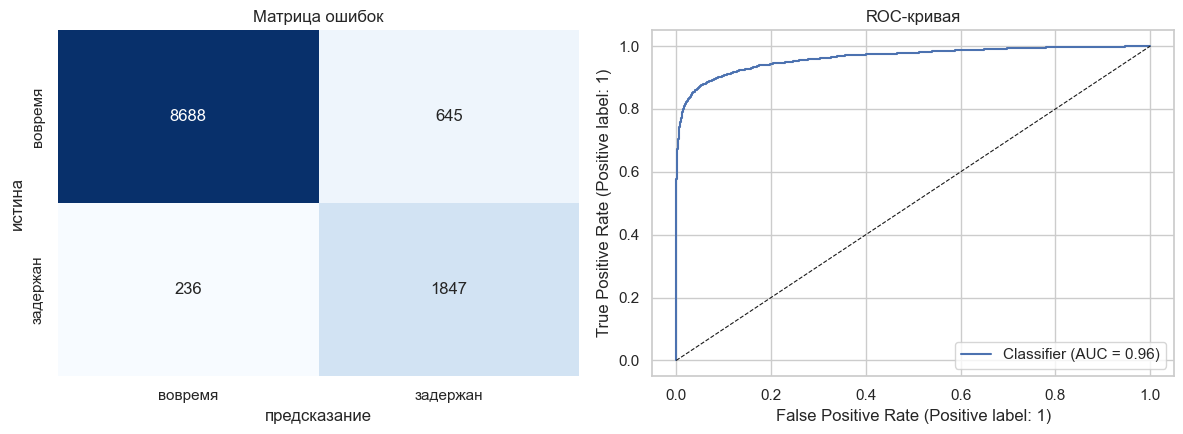

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["вовремя", "задержан"],
            yticklabels=["вовремя", "задержан"])
axes[0].set_title("Матрица ошибок")
axes[0].set_xlabel("предсказание")
axes[0].set_ylabel("истина")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC-кривая")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)

plt.tight_layout()
plt.show()

## 8. Проверка на отдельном примере

Проверяется работа конвейера в том виде, в котором он будет использоваться
сервисом: на вход подаётся единственная запись с сырыми значениями
признаков.

In [14]:
sample = {
    "AIRLINE": "United Air Lines Inc.",
    "MONTH": 3,
    "DAY_OF_WEEK": 5,
    "CRS_DEP_TIME": 735,
    "CRS_ELAPSED_TIME": 131.0,
    "DISTANCE": 811.0,
    "DEP_DELAY": 22.0,
    "TAXI_OUT": 35.0,
}

sample_df = pd.DataFrame(sample, index=[0])
probability = model.predict_proba(sample_df)[0][1]

print(f"Вероятность задержки: {probability:.3f}")
print(f"Класс: {'задержан' if probability >= 0.5 else 'вовремя'}")

Вероятность задержки: 0.973
Класс: задержан


## 9. Сохранение модели

Конвейер сохраняется целиком, вместе со всеми настроенными этапами
предварительной обработки. Сервису инференса достаточно загрузить этот файл
и передать в него сырые данные из запроса.

In [15]:
Path("../models").mkdir(parents=True, exist_ok=True)

with open("../models/pipeline.pkl", "wb") as file:
    dump(model, file)

size_kb = Path("../models/pipeline.pkl").stat().st_size / 1024
print(f"Модель сохранена: ../models/pipeline.pkl ({size_kb:.1f} КБ)")

Модель сохранена: ../models/pipeline.pkl (3.4 КБ)
